
Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)
print("\nColumns:", len(df.columns))

Saving railway_delay_analyzer_finaldataset to railway_delay_analyzer_finaldataset
Dataset loaded successfully.
Dataset shape: (50000, 40)

Columns: 40


In [6]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Date column converted successfully.")
print("Missing dates:", df["date"].isna().sum())

Date column converted successfully.
Missing dates: 0


Monthly-wise Delay Visualization

In [7]:
monthly_delay = (
    df.set_index("date")
      .resample("ME")["delay"]
      .mean()
      .reset_index()
)

print("Monthly delay analysis created.")
print(monthly_delay.head())

Monthly delay analysis created.
        date       delay
0 2025-02-28   99.647562
1 2025-03-31   88.463557
2 2025-04-30   82.361934
3 2025-05-31   90.245102
4 2025-06-30  102.646884


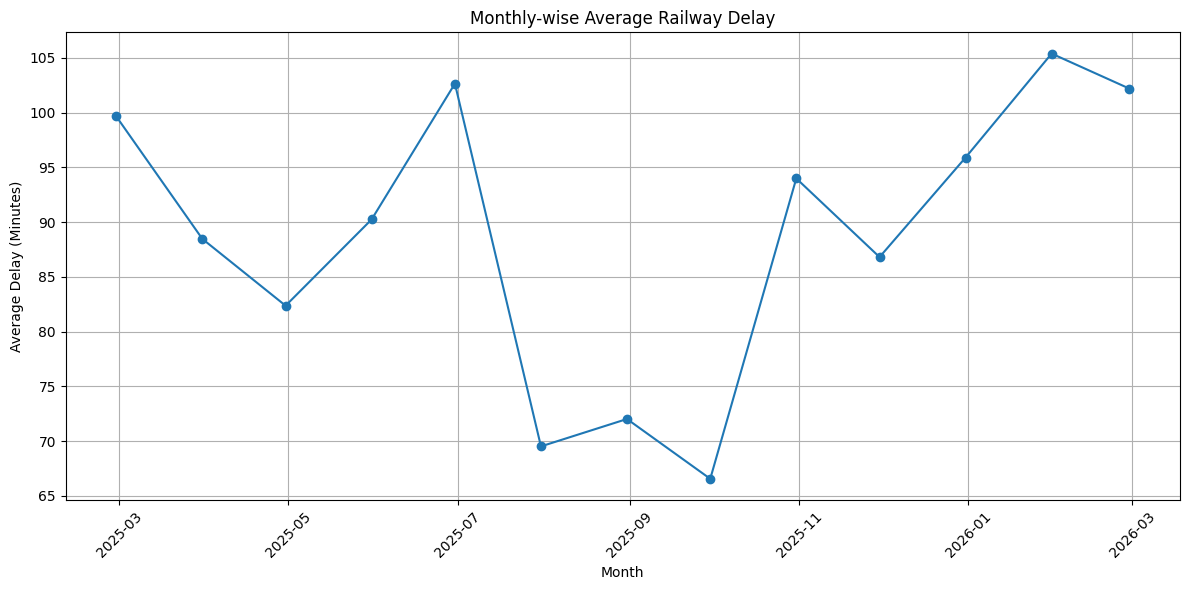

Monthly-wise delay graph created successfully.
Saved as: stage7_monthly_delay.png


In [8]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_delay["date"],
    monthly_delay["delay"],
    marker="o"
)

plt.title("Monthly-wise Average Railway Delay")
plt.xlabel("Month")
plt.ylabel("Average Delay (Minutes)")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()

plt.savefig("stage7_monthly_delay.png", dpi=300)

plt.show()

print("Monthly-wise delay graph created successfully.")
print("Saved as: stage7_monthly_delay.png")

Station-wise Delay Visualization.

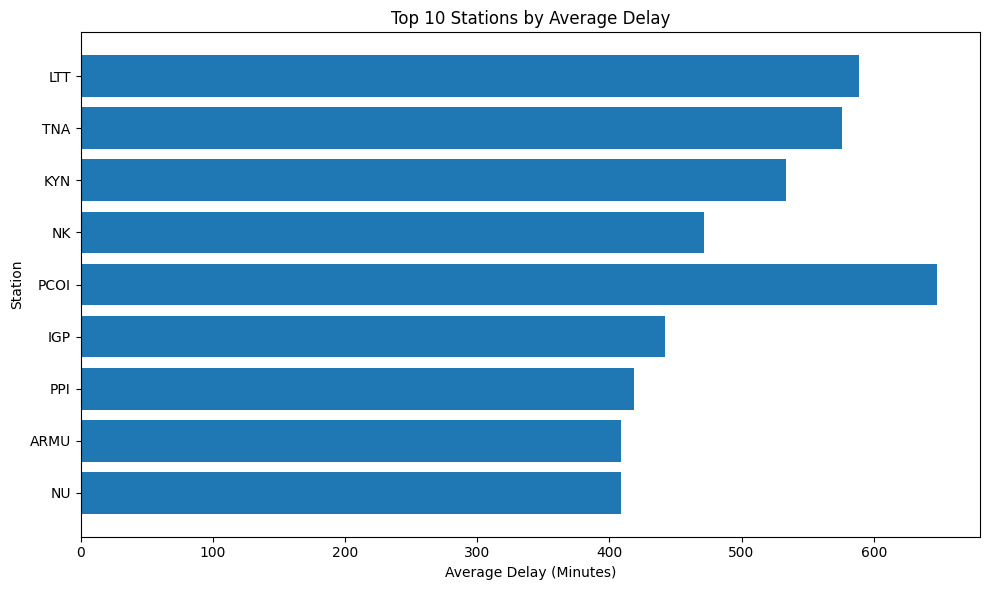

Station-wise delay graph created successfully.
Saved as: stage7_station_delay.png


In [9]:
station_analysis = (
    df.groupby(["station_no", "station_name"])
      .agg(
          average_delay=("delay", "mean"),
          total_records=("delay", "count")
      )
      .reset_index()
)

top_stations = (
    station_analysis
    .nlargest(10, "average_delay")
    .sort_values("average_delay")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_stations["station_name"].astype(str),
    top_stations["average_delay"]
)

plt.title("Top 10 Stations by Average Delay")
plt.xlabel("Average Delay (Minutes)")
plt.ylabel("Station")

plt.tight_layout()

plt.savefig("stage7_station_delay.png", dpi=300)

plt.show()

print("Station-wise delay graph created successfully.")
print("Saved as: stage7_station_delay.png")

Train-wise Delay Visualization

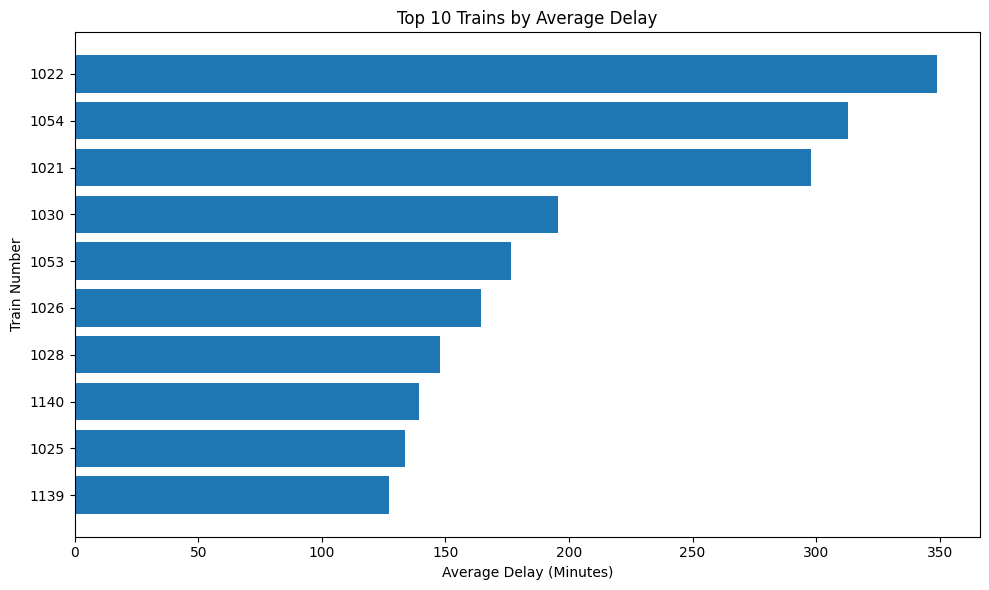

Train-wise delay graph created successfully.
Saved as: stage7_train_delay.png


In [11]:
# Train-wise delay analysis using train number

train_analysis = (
    df.groupby("train_no")
      .agg(
          average_delay=("delay", "mean"),
          total_records=("delay", "count")
      )
      .reset_index()
)

# Select top 10 trains by average delay
top_trains = (
    train_analysis
    .nlargest(10, "average_delay")
    .sort_values("average_delay")
)

# Convert train number to string for display
top_trains["train_label"] = top_trains["train_no"].astype(str)

plt.figure(figsize=(10, 6))

plt.barh(
    top_trains["train_label"],
    top_trains["average_delay"]
)

plt.title("Top 10 Trains by Average Delay")
plt.xlabel("Average Delay (Minutes)")
plt.ylabel("Train Number")

plt.tight_layout()

plt.savefig("stage7_train_delay.png", dpi=300)

plt.show()

print("Train-wise delay graph created successfully.")
print("Saved as: stage7_train_delay.png")

Special Train Delay Visualization.

In [12]:


special_mask = (
    df["type_code"].astype(str).str.contains(
        "SPECIAL",
        case=False,
        na=False
    )
    |
    df["train_name"].astype(str).str.contains(
        r"\bSPL\b|SPECIAL",
        case=False,
        na=False,
        regex=True
    )
)

special_train_analysis = (
    df[special_mask]
    .groupby("train_no")
    .agg(
        average_delay=("delay", "mean"),
        total_records=("delay", "count")
    )
    .reset_index()
)

print("Special train records found:", len(special_train_analysis))

Special train records found: 17


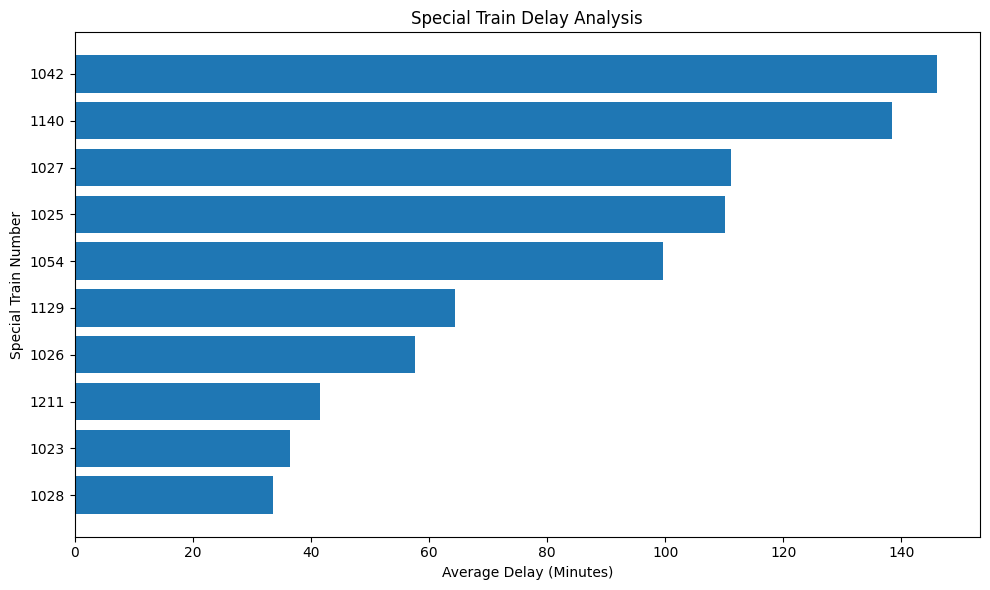

Special train delay graph created successfully.
Saved as: stage7_special_train_delay.png


In [13]:
if len(special_train_analysis) > 0:

    top_special_trains = (
        special_train_analysis
        .nlargest(10, "average_delay")
        .sort_values("average_delay")
    )

    top_special_trains["train_label"] = (
        top_special_trains["train_no"].astype(str)
    )

    plt.figure(figsize=(10, 6))

    plt.barh(
        top_special_trains["train_label"],
        top_special_trains["average_delay"]
    )

    plt.title("Special Train Delay Analysis")
    plt.xlabel("Average Delay (Minutes)")
    plt.ylabel("Special Train Number")

    plt.tight_layout()

    plt.savefig("stage7_special_train_delay.png", dpi=300)

    plt.show()

    print("Special train delay graph created successfully.")
    print("Saved as: stage7_special_train_delay.png")

else:
    print("No special-train records available for visualization.")

Weather-wise Delay Visualization.

In [14]:
weather_analysis = (
    df.groupby("weather_condition")
      .agg(
          average_delay=("delay", "mean"),
          total_records=("delay", "count")
      )
      .reset_index()
)

weather_analysis = weather_analysis.sort_values("average_delay")

print("Weather-wise analysis created.")
print(weather_analysis)

Weather-wise analysis created.
  weather_condition  average_delay  total_records
6      Humid/Cloudy      77.887781           3110
9              Rain      79.546286           6125
4        Heavy Rain      80.049477           2102
1            Cloudy      86.362133          10822
5         Hot & Dry      87.522795           1689
8     Partly Cloudy      87.584147           5122
7        Light Rain      90.673254            759
0             Clear      91.014439          16830
2      Cool & Clear      95.869375           1600
3          Fog/Mist     103.134709           1841


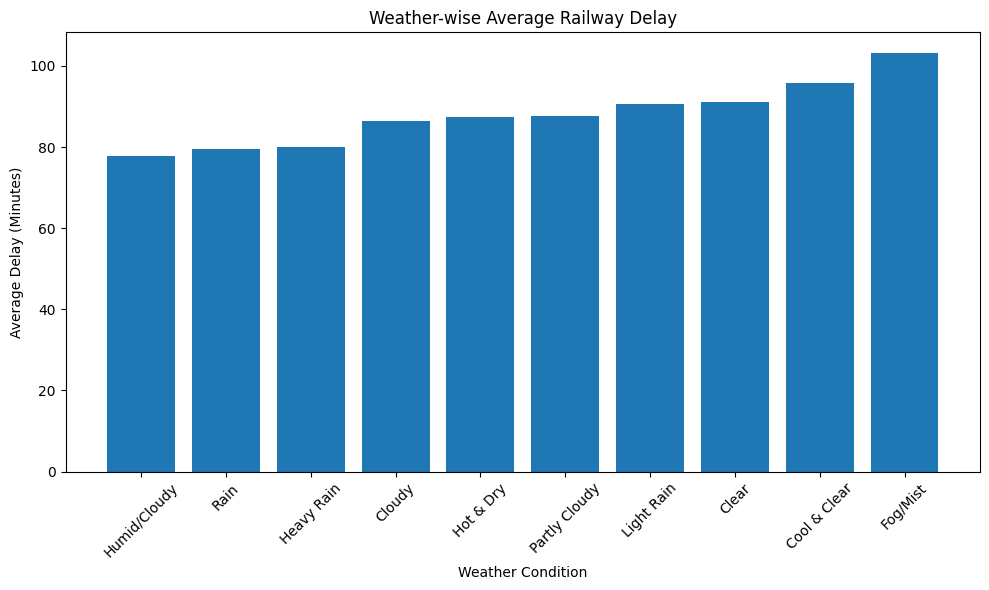

Weather-wise delay graph created successfully.
Saved as: stage7_weather_delay.png


In [15]:
plt.figure(figsize=(10, 6))

plt.bar(
    weather_analysis["weather_condition"].astype(str),
    weather_analysis["average_delay"]
)

plt.title("Weather-wise Average Railway Delay")
plt.xlabel("Weather Condition")
plt.ylabel("Average Delay (Minutes)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("stage7_weather_delay.png", dpi=300)

plt.show()

print("Weather-wise delay graph created successfully.")
print("Saved as: stage7_weather_delay.png")

Congestion-wise Delay Visualization

In [16]:
congestion_analysis = (
    df.groupby("congestion_level")
      .agg(
          average_delay=("delay", "mean"),
          total_records=("delay", "count")
      )
      .reset_index()
)

congestion_analysis = congestion_analysis.sort_values(
    "average_delay"
)

print("Congestion-wise analysis created.")
print(congestion_analysis)

Congestion-wise analysis created.
  congestion_level  average_delay  total_records
1              Low       3.161880           1532
2         Moderate      23.993726          26139
0             High      93.966732          12294
3           Severe     257.635476          10035


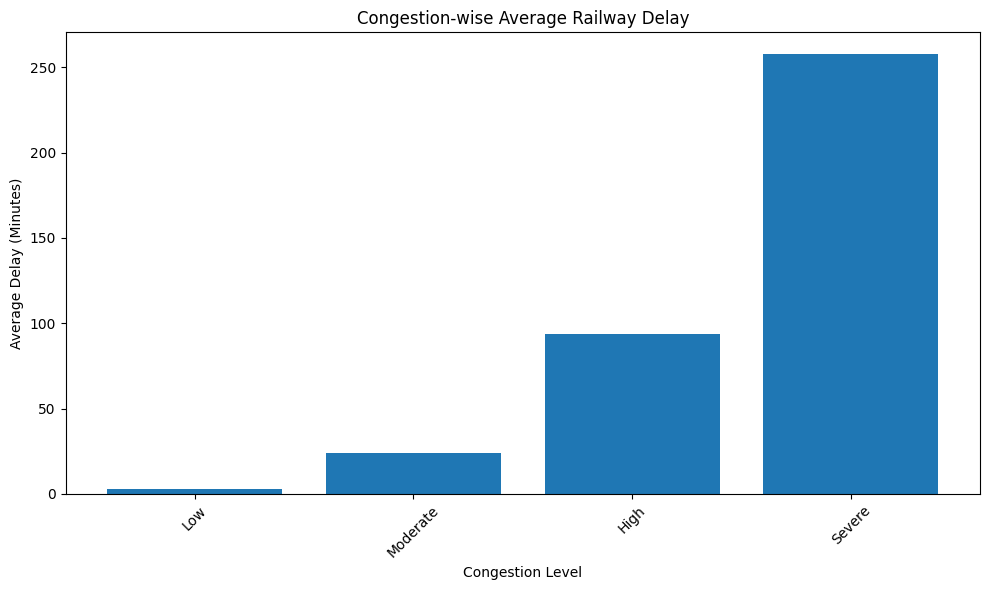

Congestion-wise delay graph created successfully.
Saved as: stage7_congestion_delay.png


In [17]:
plt.figure(figsize=(10, 6))

plt.bar(
    congestion_analysis["congestion_level"].astype(str),
    congestion_analysis["average_delay"]
)

plt.title("Congestion-wise Average Railway Delay")
plt.xlabel("Congestion Level")
plt.ylabel("Average Delay (Minutes)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("stage7_congestion_delay.png", dpi=300)

plt.show()

print("Congestion-wise delay graph created successfully.")
print("Saved as: stage7_congestion_delay.png")

Check all visualization files

In [18]:
import os

visualization_files = [
    "stage7_monthly_delay.png",
    "stage7_station_delay.png",
    "stage7_train_delay.png",
    "stage7_special_train_delay.png",
    "stage7_weather_delay.png",
    "stage7_congestion_delay.png"
]

print("Stage 7 Visualization Files:\n")

for file in visualization_files:
    if os.path.exists(file):
        print("✓", file)
    else:
        print("✗", file, "- NOT FOUND")

Stage 7 Visualization Files:

✓ stage7_monthly_delay.png
✓ stage7_station_delay.png
✓ stage7_train_delay.png
✓ stage7_special_train_delay.png
✓ stage7_weather_delay.png
✓ stage7_congestion_delay.png
